# Apply 1550 nm laser
work around 1556.005 to dont disturb usman
- Check variation of peak 2 and 2N against fluctuations of power
- If possible, check variation of peaks 2 and 2N against variations of training parameters
- Check variation of baseline against fluctuations of power: $\int_{\lambda_1}^{\lambda_2} d\lambda Baseline(\lambda)$


In [ ]:
# Load functions
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)

    # Step 6: Apply missagh profile to waveshaper
    #gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1543.11), peak=1, phase=0, sigma=0.4)  
    #bound_gaussian1 = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1540), 8)
    #bound_gaussian2 = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1540), 7)
    #missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1550), 1e-3, bound_gaussian1, bound_gaussian2)
    #wsh.apply_profile(missagh_profile)  


# physical_model and WaveshaperLayer.forward() need the same parameters for PAT
# coefficients, phases, normalization are for physical model
# startCombline and endCombline are for forward(), since the sweep is already stored

#TODO? add phase matching data if necessary
#TODO run the dual model sim using physical_model as forward and backward, just to make sure the code works without needing hardware
def physical_model(coefficients, phases, normalization, startCombline, endCombline, z=1):
    N = coefficients.size(0)
    coefficients = torch.unsqueeze(coefficients,0)
    # Prepend NaN to coefficients and phases
    nan_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
    C = torch.cat((nan_tensor, coefficients), dim=1)
    k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

    intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

    # Use vectorized operations where possible
    m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
    odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
    even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

    js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
    for m in odd_m:

        valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
        j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
        term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
        intensity[:, m[0]] = term.sum(dim=1)

    for m in even_m:
        if m[0, 0] == 2 or m[0, 0] == 2 * N:
            intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
        else:
            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
            exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
            middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)
            term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
            term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)
            intensity[:, m[0]] = (term1 * term2).real
            
    return torch.abs(intensity[:, 2:2 * N + 1])

import os

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


In [ ]:
# Load datasets
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import imageio  # Import the imageio library

# ===== MODEL A: make_moons dataset =====
# Step 1: Generate the make_moons dataset
X_A, y_A = make_moons(n_samples=70, noise=0.15, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min_A = np.min(X_A, axis=0)
X_max_A = np.max(X_A, axis=0)
X_scaled_0_1_A = (X_A - X_min_A) / (X_max_A - X_min_A)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1_A = 2 * X_scaled_0_1_A - 1

# Step 4: Split the dataset into training and testing sets
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_scaled_neg1_1_A, y_A, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train_A = torch.tensor(X_train_A, dtype=torch.float32)
X_test_A = torch.tensor(X_test_A, dtype=torch.float32)
y_train_A = torch.tensor(y_train_A, dtype=torch.float32)
y_test_A = torch.tensor(y_test_A, dtype=torch.float32)

# ===== MODEL B: make_circles dataset =====
# Step 1: Generate the make_circles dataset
X_B, y_B = make_circles(n_samples=70, factor=0.5, noise=0.1, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min_B = np.min(X_B, axis=0)
X_max_B = np.max(X_B, axis=0)
X_scaled_0_1_B = (X_B - X_min_B) / (X_max_B - X_min_B)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1_B = 2 * X_scaled_0_1_B - 1

# Step 4: Split the dataset into training and testing sets
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_scaled_neg1_1_B, y_B, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train_B = torch.tensor(X_train_B, dtype=torch.float32)
X_test_B = torch.tensor(X_test_B, dtype=torch.float32)
y_train_B = torch.tensor(y_train_B, dtype=torch.float32)
y_test_B = torch.tensor(y_test_B, dtype=torch.float32)


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   success
Applying profile...   success
Applying profile...   success
Sweep complete.


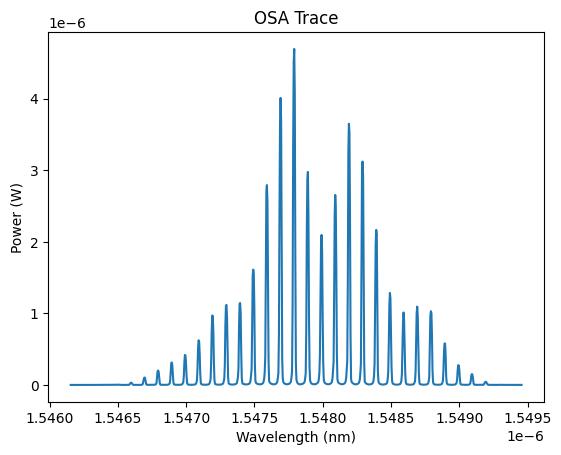

In [3]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour
from pat import make_pat_func

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

n_comblines = 15
separation_comblines = 0.2
initial_wl = 1546.005+2*0.2
# === Calibrate ===
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
peaks = np.ones(n_comblines)
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
apply_waveshaper_profile(comblines, phases, phases, channels, plot = False)
apply_waveshaper_profile(comblines, peaks, phases, channels, plot = False)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.mean(comblines))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
osa.plot_trace(wavelengths, power)

Sweep complete.
the power is 601


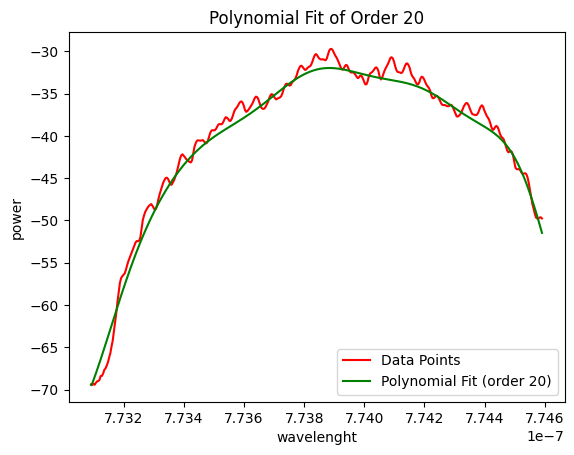

The len prominence is 376
number of maximum points 34
-1.3683532584960691


Text(0, 0.5, 'Amplitude')

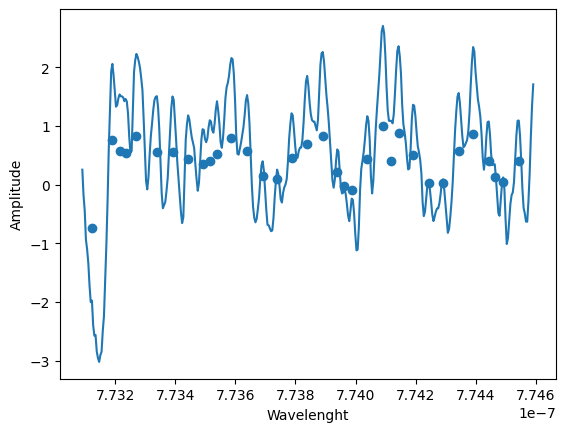

In [4]:
# Perform calibration
order = 20
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='log')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
print(f'The len prominence is {len(wavelength_trim)}')
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=20e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
normalization = 1/(fraction_max_min*max_y[0])
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')


Sweep complete.
the power is 601


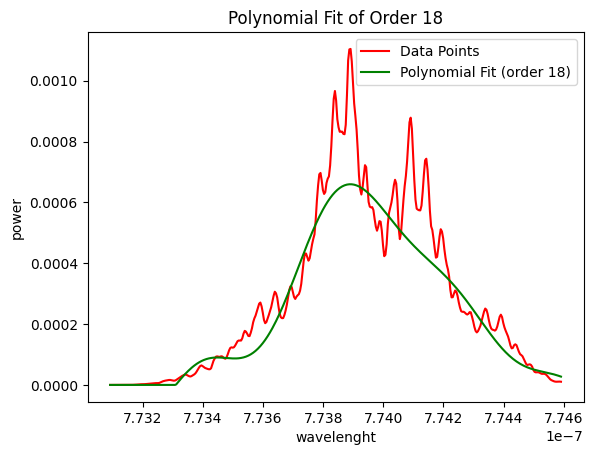

number of maximum points 28
4.408931144951192


Text(0, 0.5, 'Amplitude')

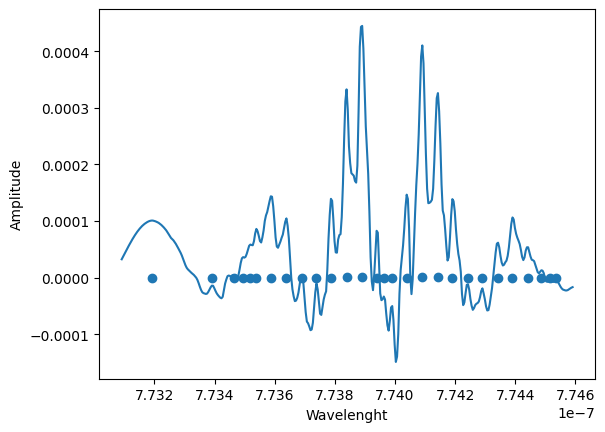

In [5]:
# Perform calibration
order = 18
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='lin')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=1e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
#normalization = 1/(fraction_max_min*max_y[0])
normalization = np.max(power)
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')

In [ ]:
# Waveshaper layer
comblines = n_comblines
#max_indices = np.arange(11,29*12,12)
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
lambda_1 = initial_wl  # Example value in nm
delta_lambda = separation_comblines  # Example value in nm
m = np.arange(1,2*comblines,1)  # Example mode number

targets = lambda_m(lambda_1, delta_lambda, m)* 1e-9
print(f"λ_m = {targets}")

wavelengths_nm = wavelength_trim 
max_indices = [np.argmin(np.abs(wavelengths_nm - t)) for t in targets]
print(f"Indices {max_indices}")

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        #self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma

        self.intensities = torch.zeros((1, 2 * len(comblines) + 1), dtype=torch.float)
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        # Trainable phases
        # self.phases = nn.Parameter(torch.zeros(len(comblines)))
        
    def performOSASweep(self, peaks, phi, normalization):
        # Generate signal profile for each combline
        apply_waveshaper_profile(self.comblines, peaks, phi, self.channels)

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, level=0.005, sensitivity = "high2", resolution = 0.02)
        # Use scipy's find_peaks to find local maxima in the inverted signal (i.e., local minima in original)
        prominence = measurement - self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[initrang:finrang]
        
        max_y = np.array(prominence_trim)[max_indices]
        # Convert max_y (NumPy array) back to a tensor
        max_y_tensor = (torch.tensor(max_y, dtype=torch.float32)/normalization)*10
        #print(f"The output from OSA is {torch.unsqueeze(max_y_tensor,0)}")
        self.intensities = torch.unsqueeze(max_y_tensor,0)


    # physical_model and WaveshaperLayer.forward() need the same parameters for PAT
    # coefficients, phases, normalization are for physical model
    # startCombline and endCombline are for forward(), since the sweep is already stored
    
    def forward(self, peaks, phi, normalization, startCombline, endCombline):    
        # Return sliced tensor of intensities, from 2*startCombline to 2*endCombline inclusive
        return self.intensities[:, 2*startCombline:2*endCombline+1]
    

λ_m = [7.73202500e-07 7.73252503e-07 7.73302513e-07 7.73352529e-07
 7.73402552e-07 7.73452581e-07 7.73502616e-07 7.73552659e-07
 7.73602707e-07 7.73652762e-07 7.73702824e-07 7.73752892e-07
 7.73802966e-07 7.73853047e-07 7.73903134e-07 7.73953228e-07
 7.74003329e-07 7.74053435e-07 7.74103549e-07 7.74153669e-07
 7.74203795e-07 7.74253928e-07 7.74304067e-07 7.74354213e-07
 7.74404365e-07 7.74454524e-07 7.74504689e-07 7.74554861e-07
 7.74605040e-07]
Indices [np.int64(28), np.int64(40), np.int64(53), np.int64(65), np.int64(78), np.int64(90), np.int64(103), np.int64(115), np.int64(128), np.int64(140), np.int64(153), np.int64(165), np.int64(178), np.int64(191), np.int64(203), np.int64(216), np.int64(228), np.int64(241), np.int64(253), np.int64(266), np.int64(278), np.int64(291), np.int64(303), np.int64(316), np.int64(328), np.int64(341), np.int64(353), np.int64(366), np.int64(375)]


In [ ]:
# Create a Model
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
channels = np.ones(n_comblines)

# Create the layer and pass input peaks
layer = WaveshaperLayer(osa, comblines=comblines, channels=channels, baseline=poly)

#this code is used to construct the PAT functions
pat_implementation = make_pat_func(layer.forward, physical_model)




class DualPhysical_NN_SHG(nn.Module):
    #TODO this is a lot of ugly repeated code, because we have all the parameters and steps for both
    #       models packed together in a joint model (intermediate layer data from both models is needed for OSA, which is ugly or impossible to sync between discrete models)
    #       In the future when we want to do this for >2 models, it's probably best to do all this with arrays or tensors or something we can iterate throughfor properly generic code
    #       Or, if we're training one model but running multiple batches simultaneously, we can just have one set of parameters
    def __init__(self, AstartCombline, AendCombline, BstartCombline, BendCombline):
        super(DualPhysical_NN_SHG, self).__init__()
        A_hidden_dim = AendCombline - AstartCombline + 1
        self.Aalpha = nn.Parameter(torch.zeros(2 * A_hidden_dim - 1))
        self.Abias = nn.Parameter(torch.zeros(1))
        self.Aphases = nn.Parameter(torch.randn(len(comblines)))
        self.Afc = nn.Linear(X_train_A.size(1), A_hidden_dim)
        self.Aln = nn.LayerNorm(2 * A_hidden_dim - 1)
        # 0 indexed, inclusive on both ends
        self.AstartCombline = AstartCombline
        self.AendCombline = AendCombline

        B_hidden_dim = BendCombline - BstartCombline + 1
        self.Balpha = nn.Parameter(torch.zeros(2 * B_hidden_dim - 1))
        self.Bbias = nn.Parameter(torch.zeros(1))
        self.Bphases = nn.Parameter(torch.randn(len(comblines)))
        self.Bfc = nn.Linear(X_train_B.size(1), B_hidden_dim)
        self.Bln = nn.LayerNorm(2 * B_hidden_dim - 1)
        # 0 indexed, inclusive on both ends
        self.BstartCombline = BstartCombline
        self.BendCombline = BendCombline

        # Initialize fc_logvar: weights around 0 and bias to a negative value (e.g. -1.0).

        nn.init.normal_(self.Afc.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.Afc.bias, 0)
        nn.init.normal_(self.Bfc.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.Bfc.bias, 0)

    
    def forward(self, xA, xB, normalization):
        # Expect x to be a 2-element tensor: [x0, x1]
        # x0, x1 = x[0], x[1]

        # x0_val = x0 if x0 > 0 else -x0
        # phi0   = 0.0 if x0 > 0 else np.pi * x0

        # x1_val = x1 if x1 > 0 else -x1
        # phi1 = 0.0 if x1 > 0 else np.pi * x1

        # ones = torch.ones(1, dtype=x.dtype, device=x.device)
        # x_cat = torch.cat((
        #     ones,
        #     torch.tensor([x0_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones.repeat(3),
        #     torch.tensor([x1_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones
        # ), dim=0)

        # phi = torch.tensor(
        #     [0.0] + [phi0] * 5 + [0.0] * 3 + [phi1] * 5 + [0.0],
        #     dtype=x.dtype, device=x.device
        # )+self.phases


        # Apply the custom PAT layer.

        xA = self.Afc(xA)
        xB = self.Bfc(xB)
        #x = self.ln1(x)
        print(f"The input of pat {xA}, {xB}")
        Aphase = torch.where(xA < 0, torch.tensor(np.pi, device=xA.device), torch.tensor(0.0, device=xA.device))
        xA = torch.abs(xA)
        Bphase = torch.where(xB < 0, torch.tensor(np.pi, device=xB.device), torch.tensor(0.0, device=xB.device))
        xB = torch.abs(xB)
        if not isinstance(normalization, torch.Tensor):
            normalization = torch.tensor(normalization, dtype=torch.float32, device=xA.device)
        
        # Construct full amplitude array for entire frequency space
        full_peaks = torch.zeros(len(comblines), dtype=xA.dtype, device=xA.device)
        full_peaks[self.AstartCombline:self.AendCombline+1] = xA
        full_peaks[self.BstartCombline:self.BendCombline+1] = xB
        
        # Construct full phases array for entire frequency space
        full_phases = torch.zeros(len(comblines), dtype=xA.dtype, device=xA.device)
        full_phases[self.AstartCombline:self.AendCombline+1] = self.Aphases[self.AstartCombline:self.AendCombline+1]*xA + Aphase
        full_phases[self.BstartCombline:self.BendCombline+1] = self.Bphases[self.BstartCombline:self.BendCombline+1]*xB + Bphase
        
        #perform SHG and OSA measurement. Results are stored internally in waveshaper layer
        #TODO speedup by jumping over the gap
        layer.performOSASweep(full_peaks, full_phases, normalization)
        #perform PAT for both models. Forward it just retrieves the relevant slice of the OSA measurement
        outA = pat_implementation(xA, self.Aphases*xA+Aphase, normalization, self.AstartCombline, self.AendCombline)
        outA = self.Aln(outA) 
        outB = pat_implementation(xB, self.Bphases*xB+Bphase, normalization, self.BstartCombline, self.BendCombline)
        outB = self.Bln(outB)
       # print(f"The output from the pat is {out}, norm {normalization}")

        # Final linear transformation.
        #TODO why is this not just a linear layer?
        outA = torch.matmul(outA, self.Aalpha) + self.Abias
        outB = torch.matmul(outB, self.Balpha) + self.Bbias
        return outA, outB



In [ ]:
name_of_experiment = "experiment_dual_01"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 18

# Convert y_train_A and y_train_B to have values 0 and 1 for binary classification
import json

y_train_binary_A = (y_train_A > 0).float()
y_test_binary_A = (y_test_A > 0).float()
y_train_binary_B = (y_train_B > 0).float()
y_test_binary_B = (y_test_B > 0).float()

def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X_A, y_A, X_B, y_B, model, epoch, normalization, nameA, nameB):
    # Create meshgrids for both datasets
    x_min_A, x_max_A = X_A[:, 0].min(), X_A[:, 0].max() + 0.2
    y_min_A, y_max_A = X_A[:, 1].min(), X_A[:, 1].max() + 0.2
    xx_A, yy_A = np.meshgrid(np.arange(x_min_A, x_max_A, 0.2),
                             np.arange(y_min_A, y_max_A, 0.2))
    
    x_min_B, x_max_B = X_B[:, 0].min(), X_B[:, 0].max() + 0.2
    y_min_B, y_max_B = X_B[:, 1].min(), X_B[:, 1].max() + 0.2
    xx_B, yy_B = np.meshgrid(np.arange(x_min_B, x_max_B, 0.2),
                             np.arange(y_min_B, y_max_B, 0.2))
    
    grid_A = np.c_[xx_A.ravel(), yy_A.ravel()]
    grid_A_tensor = torch.tensor(grid_A, dtype=torch.float32)
    
    grid_B = np.c_[xx_B.ravel(), yy_B.ravel()]
    grid_B_tensor = torch.tensor(grid_B, dtype=torch.float32)

    Z_A = np.empty(grid_A_tensor.shape[0])
    Z_B = np.empty(grid_B_tensor.shape[0])
    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_A_tensor.shape[0]):
            out_A, out_B = model(grid_A_tensor[point_idx], grid_B_tensor[point_idx], normalization)
            z_value_A = torch.tanh(out_A)
            z_value_B = torch.tanh(out_B)
            Z_A[point_idx] = z_value_A.item()
            Z_B[point_idx] = z_value_B.item()
        
    Z_A = Z_A.reshape(xx_A.shape)
    Z_B = Z_B.reshape(xx_B.shape)

    # Save meshgrid and data points for both models
    save_meshgrid_and_data(xx_A, yy_A, Z_A, X_A, y_A, nameA)
    save_meshgrid_and_data(xx_B, yy_B, Z_B, X_B, y_B, nameB)

    # Plotting with subplots - both models side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Model A (Make Moons)
    ax1.contourf(xx_A, yy_A, Z_A, alpha=0.8, cmap=plt.cm.Spectral)
    ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)
    ax1.set_title(f'{nameA} - Epoch {epoch}')
    
    # Plot Model B (Make Circles)
    ax2.contourf(xx_B, yy_B, Z_B, alpha=0.8, cmap=plt.cm.Spectral)
    ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
    ax2.set_title(f'{nameB} - Epoch {epoch}')
    
    plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundary_{epoch}.png')
    plt.close()

def train(model, X_train_A, X_train_B, y_train_binary_A, y_train_binary_B, optimizer, epoch, loss_history, normalization):
    model.train()
    epoch_loss = 0
    for data in range(X_train_A.shape[0]):
        optimizer.zero_grad()
        # Train both models
        output_A, output_B = model(X_train_A[data], X_train_B[data], normalization)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/traces/trace_data_{epoch}_{data}.csv")
        #osa.save_image('data3', f'trace_data_{epoch}_{data}_paper')
        print(f'The train binary A is {y_train_binary_A[data]}; the output A is {output_A}')
        print(f'The train binary B is {y_train_binary_B[data]}; the output B is {output_B}')
        loss_A = criterion(output_A, y_train_binary_A[data].unsqueeze(0))
        loss_B = criterion(output_B, y_train_binary_B[data].unsqueeze(0))
        loss = loss_A + loss_B
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / X_train_A.shape[0]
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
def test(model, X_test_A, X_test_B, y_test_A, y_test_B, normalization):
    predicted_classes_A = []
    predicted_classes_B = []
    with torch.no_grad():
        for data in range(X_test_A.shape[0]):
            y_pred_A, y_pred_B = model(X_test_A[data], X_test_B[data], normalization)
            y_pred_A = torch.sigmoid(y_pred_A)
            y_pred_B = torch.sigmoid(y_pred_B)
            predicted_classes_A.append(y_pred_A.item())
            predicted_classes_B.append(y_pred_B.item())

    # Convert to NumPy arrays
    predicted_classes_A = np.array(predicted_classes_A)
    predicted_classes_B = np.array(predicted_classes_B)
    y_test_A = y_test_A.numpy()
    y_test_B = y_test_B.numpy()

    # Calculate accuracies
    accuracy_A = accuracy_score((y_test_A > 0.5), (predicted_classes_A > 0.5))
    accuracy_B = accuracy_score((y_test_B > 0.5), (predicted_classes_B > 0.5))
    print(f'Accuracy A: {accuracy_A:.4f}')
    print(f'Accuracy B: {accuracy_B:.4f}')
    return accuracy_A, accuracy_B

interval_images = 1


# Step 4: Train the Model
from torch.optim.lr_scheduler import LambdaLR
model = DualPhysical_NN_SHG(AstartCombline=0, AendCombline=3, BstartCombline=11, BendCombline=14)
#checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_init1.pth', map_location=torch.device('cpu'))
#state_dict = checkpoint['model_state_dict']
#model.load_state_dict(state_dict, strict=True)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.BCEWithLogitsLoss()#nn.MSELoss()  # Binary Cross-Entropy Loss with logits
#model.train()


def lr_lambda(epoch):
    if epoch < 8:
        return 1          # 0.008 * 1.0 = 0.008 for epochs 0-9
    elif epoch < 12:
        return 0.1          # 0.008 * 0.25 = 0.002 for epochs 10-19
    elif epoch < 16:
        return 0.01         # 0.008 * 0.125 = 0.001 for epochs 20-29
    else:
        return 0.02        # 0.008 * 0.0125 = 0.0001 for epoch 30 and beyond

# Create the learning rate scheduler using LambdaLR
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

import pandas as pd  # For saving data to CSV

# Initialize a dictionary to store power measurements
power_measurements = {}
for i in range(2*n_comblines-1):  
    power_measurements[f"peak{i}"] = []
# Training loop with visualization and periodic measurements

loss_history = []


for epoch in range(epochs):
    train(model, X_train_A, X_train_B, y_train_binary_A, y_train_binary_B, optimizer, epoch, loss_history, normalization)
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    
    # Stop training if the loss is below the threshold
    if avg_loss < 0.001:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break
    
    accuracy_A, accuracy_B = test(model, X_test_A, X_test_B, y_test_binary_A, y_test_binary_B, normalization)
    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'accuracy_A': accuracy_A,
        'accuracy_B': accuracy_B
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')
    scheduler.step()
    # Perform measurement every 10 epochs
    if (epoch + 1) % 1 == 0:
        peaks_decopling = np.ones(n_comblines)
        phases_decopling = np.zeros(n_comblines)
        channels_decopling = np.ones(n_comblines)

        apply_waveshaper_profile(comblines, peaks_decopling, phases_decopling, channels_decopling, plot = False)
        wav, power = osa.perform_measurement_OSA(center=np.mean(comblines)/2, span=(np.max(comblines)-np.mean(comblines))+0.5, level=0.006, sensitivity = "high3", resolution = 0.02)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}.csv")
        normalization = np.max(power)
        # Store power at specified indices

        for i, index in enumerate(max_indices):
            power_measurements[f"peak{i}"].append(power[index])
        print(f"Coupling loss measurements taken at epoch {epoch + 1}")
        
# Save power measurements to a CSV file
df = pd.DataFrame([power_measurements])  # Convert dictionary to a DataFrame
df.to_csv(f'./data_runs/{name_of_experiment}/spectral_consistency.csv', index=False)
print("Power measurements saved to spectral_consistency.csv")

# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

# Plot the final decision boundary for both models
plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, epoch, normalization, "Moons", "Circles")



Folders ensured:
- data_runs\experiment_moons_09\stability
- data_runs\experiment_moons_09\checkpoints
- data_runs\experiment_moons_09\traces
The input of pat tensor([ 0.0447, -0.1250,  0.9296,  0.2540, -0.0126, -0.3862,  0.8175,  0.1378,
        -0.5416, -0.4787,  0.7421,  0.8870,  0.0702,  0.3895,  0.3164],
       grad_fn=<ViewBackward0>)
Applying profile...   success
Sweep complete.
The train binary is 0.0; the output binary is tensor([0.], grad_fn=<AddBackward0>)


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10176\1991677635.py:102: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  intensity[:, m[0]] = term.sum(dim=1)


The input of pat tensor([ 1.4229e-01,  1.3470e-01, -6.4433e-02,  8.1132e-02,  1.5109e-02,
         1.8551e-04, -4.1830e-02,  1.5692e-01,  6.2262e-02,  1.9684e-01,
         7.3347e-02, -2.2046e-01, -1.0367e-01, -1.4113e-02, -4.1844e-04],
       grad_fn=<ViewBackward0>)
Applying profile...   success
Sweep complete.


KeyboardInterrupt: 

In [ ]:
# Plot the final decision boundary for both models
plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, 1000, normalization, "Model A", "Model B")

The input of pat tensor([  3.6645,   3.8265,   5.1466,   4.6844,   5.5122,  -4.7702,   4.9094,
          6.1719,  -1.1032,   7.9724, -14.4097,  -1.6958,  -0.8339,   2.5524,
          3.4148])
Applying profile...   success
Sweep complete.
The input of pat tensor([  4.9424,   5.3600,   6.6960,   5.9830,   7.1850,  -6.6303,   6.5013,
          8.0808,  -2.7304,  10.0970, -11.2265,  -1.5359,  -1.8382,   4.0029,
          4.6740])
Applying profile...   success
Sweep complete.
The input of pat tensor([ 6.2203,  6.8935,  8.2455,  7.2816,  8.8579, -8.4905,  8.0932,  9.9898,
        -4.3576, 12.2216, -8.0432, -1.3760, -2.8424,  5.4535,  5.9331])
Applying profile...   success
Sweep complete.
The input of pat tensor([  7.4982,   8.4270,   9.7949,   8.5802,  10.5307, -10.3506,   9.6851,
         11.8987,  -5.9848,  14.3462,  -4.8600,  -1.2161,  -3.8467,   6.9040,
          7.1923])
Applying profile...   success
Sweep complete.
The input of pat tensor([  8.7760,   9.9605,  11.3444,   9.8788,  12.20

In [12]:
!git add .
!git commit -m "working"
!git push origin main

[main 7659f87] working
 3 files changed, 6681 insertions(+), 16930 deletions(-)
 delete mode 100644 ws.log.0


To https://github.com/daalopezm/Physical_NN_SHG.git
   5baa10d..7659f87  main -> main


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10176\2905185465.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


model_checkpoint0.pth: Loss = 0.7301136067935399
model_checkpoint1.pth: Loss = 0.6713689948831286
model_checkpoint2.pth: Loss = 0.5052407728774208
model_checkpoint3.pth: Loss = 0.3243933953344822
model_checkpoint4.pth: Loss = 0.1995852239962135
model_checkpoint5.pth: Loss = 0.1401064753798502
model_checkpoint6.pth: Loss = 0.06997753027161317
model_checkpoint7.pth: Loss = 0.06377878482453525
model_checkpoint8.pth: Loss = 0.05427013448373016
model_checkpoint9.pth: Loss = 0.05839162552729249
model_checkpoint10.pth: Loss = 0.06029669209716043
model_checkpoint11.pth: Loss = 0.0642878055905125
model_checkpoint12.pth: Loss = 0.06940103091765196
model_checkpoint13.pth: Loss = 0.069400030900059
model_checkpoint14.pth: Loss = 0.07098004292763238
model_checkpoint15.pth: Loss = 0.06866032105670976
model_checkpoint16.pth: Loss = 0.06822288601792284
model_checkpoint17.pth: Loss = 0.06940026735288224
model_checkpoint0.pth: Accuracy = 0.4
model_checkpoint1.pth: Accuracy = 0.4
model_checkpoint2.pth: Ac

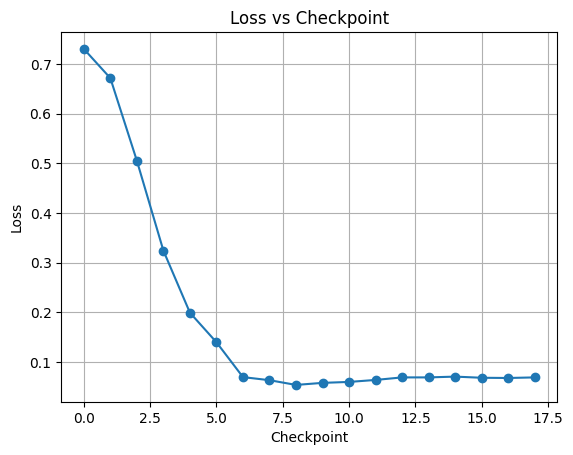

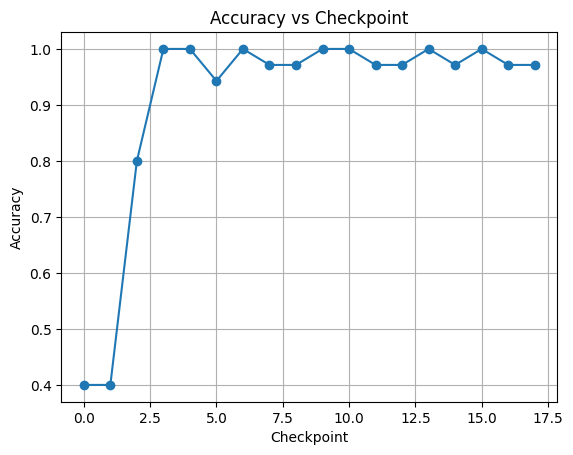

In [ ]:
import torch
import os

# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"
#directory = f"./data_runs/experiment_moons_08/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
losses = []
accuracies = []

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)
        
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'loss' in checkpoint:
            loss = checkpoint['loss']
            losses.append((filename, loss))
        else:
            print(f"Loss not found in {filename}")

        if 'accuracy_score' in checkpoint:
            accuracy = checkpoint['accuracy_score']
            accuracies.append((filename, accuracy))
        else:
            print(f"Accuracy not found in {filename}")

# Print the extracted losses
for filename, loss in losses:
    print(f"{filename}: Loss = {loss}")

# Print the extracted losses
for filename, accuracy in accuracies:
    print(f"{filename}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt

# Extracting just the loss values for plotting
loss_values = [loss for _, loss in losses]
plt.plot(loss_values, marker='o')
plt.title("Loss vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Extracting just the loss values for plotting
accuracy_values = [accuracy for _, accuracy in accuracies]
plt.plot(accuracy_values, marker='o')
plt.title("Accuracy vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [9]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed


In [ ]:
import torch

# Load the .pth file
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint10.pth', map_location=torch.device('cpu'))
print(type(checkpoint))
checkpoint['model_state_dict']


<class 'dict'>


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10156\2629051906.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'./data_runs/{name_of_experimen

OrderedDict([('alpha',
              tensor([-0.0125, -0.0176, -0.0232, -0.0183, -0.0027, -0.0443, -0.0145, -0.2646,
                      -0.0248, -0.5596,  0.1471, -0.1097, -0.1492, -0.1778,  0.0481,  0.0646,
                       0.2945,  0.0266,  0.3211,  0.1230, -1.1382, -0.1040,  0.2167,  0.2027,
                       0.2118, -0.0827,  0.0591,  0.0096,  0.0081])),
             ('bias', tensor([-0.0108])),
             ('phases',
              tensor([-0.1714,  0.0290, -0.0602,  0.3793, -0.0110,  0.0763,  0.0540, -0.0922,
                      -0.6505,  0.1497,  0.5390,  3.1698, -1.0237, -0.3132,  0.2370])),
             ('fc.weight',
              tensor([[ 2.6431, -0.6957],
                      [ 2.9011, -0.4326],
                      [ 2.1585, -0.7287],
                      [ 1.7431,  0.8088],
                      [ 2.4911, -1.3772],
                      [-2.8624,  0.3889],
                      [ 2.2417,  0.9271],
                      [ 2.9565, -1.5018],
              